In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert

# --------------------------------------------------
# PATHS
# --------------------------------------------------

SOLID_DIR = Path(
    "/media/dysco/New Volume/Neeraj/varflexi solver/results/best_result/solid/v18_reissner_mindlin_plate/"
)

FLUID_DIR = Path(
    "/media/dysco/New Volume/Neeraj/varflexi solver/results/best_result/fluid/v9"
)

COUPLING_DIR = Path(
    "/media/dysco/New Volume/Neeraj/varflexi solver/results/best_result/coupling"
)

FIG_DIR = Path(
    "/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/final_plots/heaving_validation/"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [2]:
# --------------------------------------------------
# PHYSICAL PARAMETERS
# --------------------------------------------------

span = 0.30
chord = 0.10

Uinf = 4.43

kG = 1.82

freq = kG*Uinf/(np.pi*chord)

omega = 2*np.pi*freq

print("Frequency =",freq)

Frequency = 25.664052883454307


In [3]:
diag = pd.read_csv(
    SOLID_DIR/"diagnostics/solid_diagnostics.csv"
)

diag.head()

,Step,Time,Root_Uz,Mid_Uz,Tip_Uz,Root_Vz,Mid_Vz,Tip_Vz,Root_Az,Mid_Az,...,DeltaE_over_E0,FluidWork,StructuralWork,CumFluidWork,CumStructuralWork,WorkError,NewtonIterations,NewtonResidual,ForceNorm,WallTime
0,1,0.005111,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1,0.000000e+00,0.000000e+00,0.000000
1,2,0.010222,3.779824e-07,-8.771569e-09,4.449725e-09,0.000147,-0.000003,0.000002,0.047832,-0.001110,...,6.838015e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2,2.236608e-13,1.966475e-13,11.618962
2,3,0.015333,1.504830e-06,3.860202e-08,1.796521e-09,0.000295,0.000022,-0.000003,0.016495,0.008921,...,4.724258e+06,9.652074e-15,9.653868e-15,9.652074e-15,9.653868e-15,0.000186,2,1.011124e-10,8.060803e-09,7.566065
3,4,0.020444,3.359303e-06,4.240183e-07,-1.978676e-07,0.000430,0.000129,-0.000075,0.033066,0.028922,...,1.289666e+07,2.713354e-13,2.713565e-13,2.809875e-13,2.810104e-13,0.000078,2,6.204158e-10,4.950822e-08,1.055465
4,5,0.025556,5.906187e-06,1.460354e-06,-1.081350e-06,0.000567,0.000277,-0.000270,0.022471,0.029071,...,2.607155e+07,2.186431e-12,2.186496e-12,2.467419e-12,2.467507e-12,0.000030,2,1.997148e-09,1.594646e-07,0.988660


In [4]:
time = diag["Time"].values

tip_disp = diag["Tip_Uz"].values

E_elas = diag["ElasticEnergy"].values
E_kin  = diag["KineticEnergy"].values
E_damp = diag["DampingEnergy"].values
E_tot  = diag["TotalEnergy"].values

Wf = diag["FluidWork"].values
Ws = diag["StructuralWork"].values
work_err = diag["WorkError"].values

In [5]:
a_root = 0.175*chord

root_disp = a_root*np.cos(
    omega*time
)

In [6]:
root_nd = root_disp/a_root

tip_nd = tip_disp/a_root

Tcycle = 1/freq

time_nd = time/Tcycle

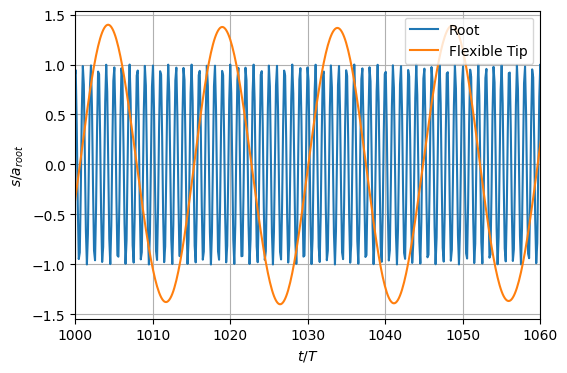

In [26]:
fig,ax = plt.subplots(
    figsize=(6,4)
)

plt.xlim(1000,1060)

ax.plot(
    time_nd,
    root_nd,
    label="Root"
)

ax.plot(
    time_nd,
    tip_nd,
    label="Flexible Tip"
)

ax.set_xlabel(
    r"$t/T$"
)

ax.set_ylabel(
    r"$s/a_{root}$"
)

ax.grid(True)

ax.legend()

fig.savefig(
    FIG_DIR/"validation_tip_displacement.pdf"
)

plt.show()

In [8]:
Aroot = (
    root_disp.max()
    -
    root_disp.min()
)/2

Atip = (
    tip_disp.max()
    -
    tip_disp.min()
)/2

amp_ratio = Atip/Aroot

print(
    "Tip amplification ratio =",
    amp_ratio
)

Tip amplification ratio = 1.4002230706264103


In [9]:
analytic_root = hilbert(root_disp)
analytic_tip  = hilbert(tip_disp)

phase_root = np.unwrap(
    np.angle(analytic_root)
)

phase_tip = np.unwrap(
    np.angle(analytic_tip)
)

phase_lag = np.mean(
    phase_tip-phase_root
)

print(
    "Mean phase lag [rad] =",
    phase_lag
)

print(
    "Mean phase lag [deg] =",
    np.degrees(phase_lag)
)

Mean phase lag [rad] = -3458.0755301085555
Mean phase lag [deg] = -198133.13311268506


In [10]:
dt = time[1]-time[0]

signal = tip_disp - np.mean(tip_disp)

fft_vals = np.fft.rfft(signal)

fft_freq = np.fft.rfftfreq(
    len(signal),
    d=dt
)

fft_amp = np.abs(fft_vals)

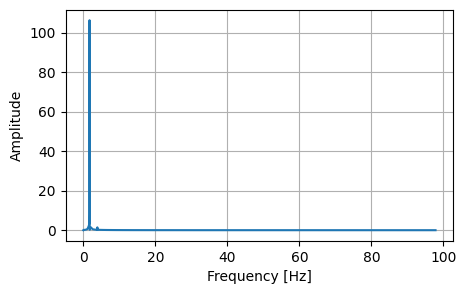

In [11]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

ax.plot(
    fft_freq,
    fft_amp
)

ax.set_xlabel(
    "Frequency [Hz]"
)

ax.set_ylabel(
    "Amplitude"
)

ax.grid(True)

fig.savefig(
    FIG_DIR/"fft_tip_response.pdf"
)

plt.show()

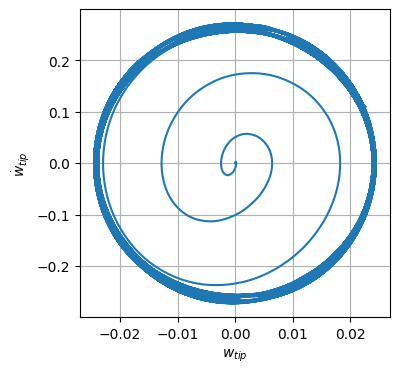

In [12]:
vel_tip = np.gradient(
    tip_disp,
    dt
)

fig,ax = plt.subplots(
    figsize=(4,4)
)

ax.plot(
    tip_disp,
    vel_tip
)

ax.set_xlabel(
    r"$w_{tip}$"
)

ax.set_ylabel(
    r"$\dot w_{tip}$"
)

ax.grid(True)

fig.savefig(
    FIG_DIR/"phase_space.pdf"
)

plt.show()

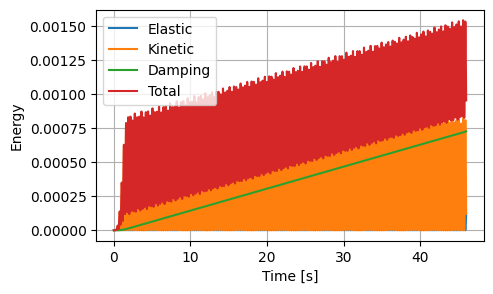

In [13]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

ax.plot(
    time,
    E_elas,
    label="Elastic"
)

ax.plot(
    time,
    E_kin,
    label="Kinetic"
)

ax.plot(
    time,
    E_damp,
    label="Damping"
)

ax.plot(
    time,
    E_tot,
    label="Total"
)

ax.legend()

ax.grid(True)

ax.set_xlabel("Time [s]")

ax.set_ylabel("Energy")

fig.savefig(
    FIG_DIR/"energy_history.pdf"
)

plt.show()

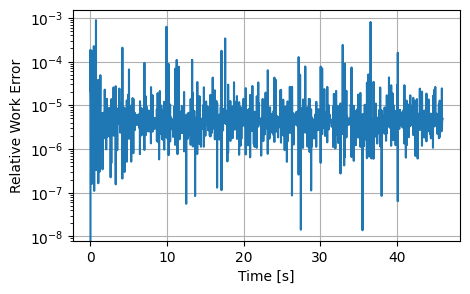

In [14]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

ax.semilogy(
    time,
    np.abs(work_err)
)

ax.set_xlabel(
    "Time [s]"
)

ax.set_ylabel(
    "Relative Work Error"
)

ax.grid(True)

fig.savefig(
    FIG_DIR/"work_conservation_error.pdf"
)

plt.show()

In [15]:
print(
    "Mean work error =",
    np.mean(work_err)
)

print(
    "Max work error =",
    np.max(work_err)
)

print(
    "RMS work error =",
    np.sqrt(
        np.mean(work_err**2)
    )
)

Mean work error = 5.480020666332891e-06
Max work error = 0.0008855982574102
RMS work error = 1.7278732708500965e-05


In [16]:
coupling = pd.read_csv(
    COUPLING_DIR/"coupling_history.csv"
)

coupling.head()

,step,n_forces,force_relax_used,force_residual,sample_fx,sample_fy,sample_fz
0,1,80,0.2,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
1,2,80,0.2,1.000000,-2.289529e-27,0.000000e+00,3.184236e-15
2,3,80,0.2,0.999997,-2.329267e-22,4.406339e-16,7.999539e-10
3,4,80,0.2,0.962981,-1.500201e-18,3.866040e-15,4.206618e-09
4,5,80,0.2,0.918688,-1.699071e-17,1.365704e-14,1.181231e-08


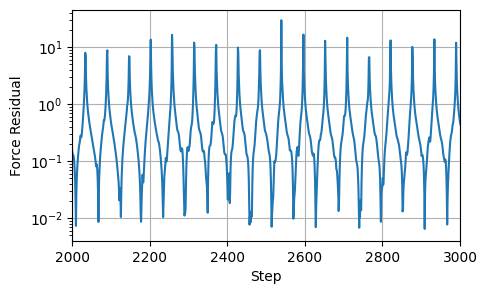

In [24]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

plt.xlim(2000,3000)

ax.semilogy(
    coupling["step"],
    coupling["force_residual"]
)

ax.set_xlabel(
    "Step"
)

ax.set_ylabel(
    "Force Residual"
)

ax.grid(True)

fig.savefig(
    FIG_DIR/"coupling_residual.pdf"
)

plt.show()

In [18]:
json_file = (
    COUPLING_DIR/
    "forces_sent_received_history.jsonl"
)

Fx = []
Fy = []
Fz = []
steps = []

with open(json_file,"r") as fp:

    for line in fp:

        rec = json.loads(line)

        f0 = rec["force_sent"][0]

        Fx.append(f0[0])
        Fy.append(f0[1])
        Fz.append(f0[2])

        steps.append(
            rec["step"]
        )

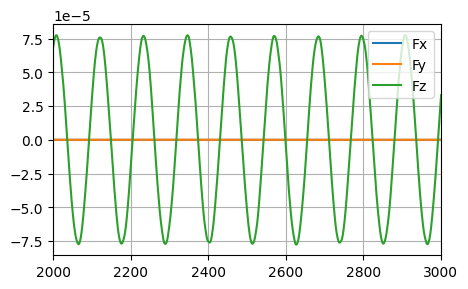

In [25]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

plt.xlim(2000,3000)

ax.plot(steps,Fx,label="Fx")
ax.plot(steps,Fy,label="Fy")
ax.plot(steps,Fz,label="Fz")

ax.legend()

ax.grid(True)

fig.savefig(
    FIG_DIR/"force_history_cp0.pdf"
)

plt.show()